# 220 — The classical MHC in the QfO region run: what is on the map

**Question:** the midi-plus run searched 998 human proteins against nine whole proteomes.
Before reading any result off it, what does it cover inside the MHC, and what can each
target proteome possibly contain?

**The run.** QfO Pfam-region benchmark, midi-plus, run 2026-09-01 to 09-02 on Sherlock
(4,723 tasks). Queries: the 964 human chromosome 6 proteins of the earlier midi run, plus
34 added off chromosome 6: B2M (the class I light chain, chr15), CD1A-E and MR1 (class
I-like molecules, chr1) and 27 KIR and LILR receptors (chr19). Targets: mouse, chicken,
zebrafish, ciona, fly, worm, yeast, *Arabidopsis* and *E. coli*, each scored against its
own Pfam annotation. A tenth target, the colonial tunicate *Botryllus schlosseri*, was
searched from 2026-09-04 to 09-10 but has no Pfam annotation and so no score; notebook 228
reads its hits. Tools: kmerseek over a sweep of alphabets and k, and nine comparison tools
(phmmer, jackhmmer, MMseqs2, MMseqs2 iterative, HHblits, Foldseek, ProstT5, Reseek,
Folddisco).

Words used in every notebook of this block. An *arm* is one tool at one setting; for
kmerseek that is one alphabet at one k, so "kmerseek hp_pbotc_1st_ed2 k=19" is one arm.
The *comparison tools* are the nine tools named above. A domain is *found* when a hit
overlaps at least half of it. A domain is *boundary matched* when the hit's interval agrees
with the domain at IoU ≥ 0.5, IoU being overlap divided by union; this is the run's own
true-positive rule and is a stricter question than found. Every figure says which tool it
draws, and names the alphabet and k whenever the tool is kmerseek.

The MHC is the wrong region to walk into without a map. It is 7.6 Mb holding several
unrelated stories at once: a class I and a class II region whose genes are jawed-vertebrate
inventions ~500 Mya old, separated by a class III region that is not immunoglobulin at all
and whose genes (complement, TNF, HSP70) run back to bacteria. A single "MHC recall" number
averages those together and means nothing.

This notebook fixes three things the later notebooks depend on:

1. where each chr6 query gene sits, and which xMHC sub-region it falls in
2. which Pfam domains the MHC genes carry, from the run's own truth set rather than from recall
3. what is *reachable*: which of those families exist at all in each target proteome

Companion notebooks: [221](./221_mhc_cross_species_detection_depth.ipynb) (how far back each
gene is detectable, and by which tool), [222](./222_mhc_synteny_target_side.ipynb) (where the
hits land in the target genome), [223](./223_mhc_platform_vs_ig_domain.ipynb) (the
peptide-binding groove versus the Ig domain in the same molecule).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_query_gene_map()
truth = mu.load_human_truth()
gencode6 = pl.read_parquet(mu.CHR6_GENCODE)

window = mu.load_mhc_window(gene_map)
extras = mu.load_mhc_extras(gene_map)
core = gene_map.filter(pl.col("mhc_class").is_not_null())
chr6 = gene_map.filter(pl.col("query_set") == "chr6")

print(mu.RUN_SUMMARY)
print()
print(f"query proteins in the midi-plus run : {gene_map.height:_}")
for qs, n in (
    gene_map.group_by("query_set").len().sort("len", descending=True).iter_rows()
):
    print(f"  {mu.QUERY_SET_LABELS[qs]:38s}: {n:_}")
print(
    f"chr6 queries with GENCODE v50 coordinates: "
    f"{chr6.filter(pl.col('midpoint').is_not_null()).height:_} of {chr6.height:_}"
)
print(f"  inside the extended MHC               : {window.height:_}")
print(
    f"curated MHC genes (ou.MHC_CLASSES)      : {core.height:_} "
    f"({core.filter(pl.col('query_set') == 'chr6').height} on chr6 + B2M)"
)
print(
    f"human Pfam domain instances scored      : {truth.height:_} "
    f"across {truth['pfam_id'].n_unique():_} families"
)
print(
    f"  on MHC-window genes                   : "
    f"{truth.filter(pl.col('accession').is_in(window['accession'].to_list())).height:_}"
)
print(
    f"  on the 34 off-chr6 additions          : "
    f"{truth.filter(pl.col('accession').is_in(extras['accession'].to_list())).height:_}"
)

Run: QfO Pfam-region benchmark, midi-plus (2026-09-01 to 09-02, 4,723 tasks). 998 human queries: 964 chromosome 6 proteins plus B2M, CD1A-E, MR1 and 27 KIR/LILR receptors. Targets: mouse, chicken, zebrafish, ciona, fly, worm, yeast, Arabidopsis and E. coli, all scored against Pfam; Botryllus schlosseri searched but unscored.

query proteins in the midi-plus run : 998
  chromosome 6                          : 964
  KIR + LILR receptors (chr19)          : 27
  CD1A-E + MR1 (class I-like, chr1)     : 6
  B2M (light chain, chr15)              : 1
chr6 queries with GENCODE v50 coordinates: 957 of 964
  inside the extended MHC               : 221
curated MHC genes (ou.MHC_CLASSES)      : 25 (24 on chr6 + B2M)
human Pfam domain instances scored      : 2_435 across 1_089 families
  on MHC-window genes                   : 599
  on the 34 off-chr6 additions          : 77


## 1. The extended MHC, and where the query set falls inside it

Sub-region boundaries are Horton et al. 2004's xMHC partition in GRCh38 coordinates
(`mu.MHC_SUBREGIONS`), assigned by gene midpoint so a gene straddling a boundary lands on
the side holding most of it. The five-way split is the point: an immunologist reads class I,
class III and class II as three different kinds of gene, and the figure has to keep them
apart.

The bottom panel is the part that matters for every later notebook. The 736 chr6 genes
*outside* the xMHC are the built-in control. The arithmetic closes as 964 = 221 in the
window + 736 outside it + 7 with no GENCODE chr6 record under their HGNC symbol (§4). Any
statement of the form "tool X does badly on the MHC" only means something against how X
does on the rest of the same chromosome, scored the same way in the same run.

The 34 queries added off chromosome 6 (B2M, CD1A-E, MR1, KIR, LILR) are not on this map
because they are not on this chromosome. Section 4 lists them.

shape: (5, 6)
┌───────────────────┬──────────┬──────────┬─────────┬────────────────┬───────────────┐
│ mhc_subregion     ┆ start    ┆ end      ┆ span_mb ┆ n_coding_genes ┆ n_query_genes │
│ ---               ┆ ---      ┆ ---      ┆ ---     ┆ ---            ┆ ---           │
│ str               ┆ i64      ┆ i64      ┆ f64     ┆ u32            ┆ u32           │
╞═══════════════════╪══════════╪══════════╪═════════╪════════════════╪═══════════════╡
│ extended class I  ┆ 25726063 ┆ 29722774 ┆ 4.0     ┆ 116            ┆ 86            │
│ class I           ┆ 29722775 ┆ 31371356 ┆ 1.65    ┆ 46             ┆ 41            │
│ class III         ┆ 31371357 ┆ 32145873 ┆ 0.77    ┆ 58             ┆ 51            │
│ class II          ┆ 32146874 ┆ 33080775 ┆ 0.93    ┆ 32             ┆ 28            │
│ extended class II ┆ 33080776 ┆ 33400644 ┆ 0.32    ┆ 17             ┆ 15            │
└───────────────────┴──────────┴──────────┴─────────┴────────────────┴───────────────┘

chr6 queries outside the xMH

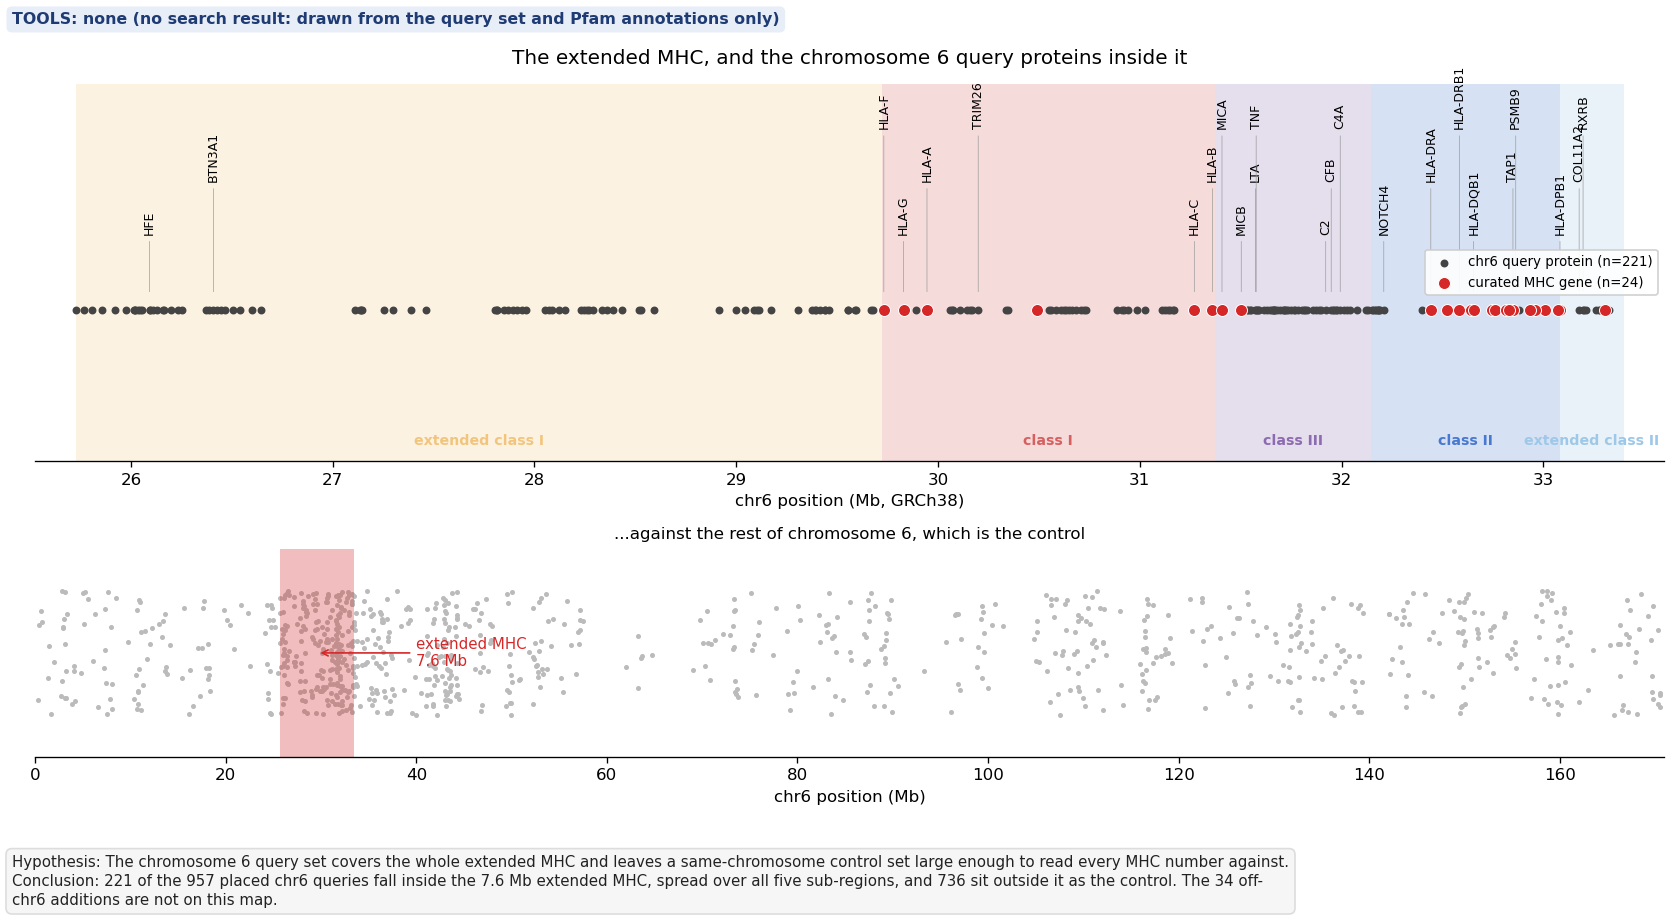

In [2]:
gm = gene_map.filter(pl.col("midpoint").is_not_null())
sub_counts = gm.group_by("mhc_subregion").len().rename({"len": "n_query_genes"})
order = mu.MHC_SUBREGION_ORDER
tbl = (
    pl.DataFrame({"mhc_subregion": order})
    .join(sub_counts, on="mhc_subregion", how="left")
    .with_columns(pl.col("n_query_genes").fill_null(0))
    .with_columns(
        start=pl.Series([lo for _, lo, _ in mu.MHC_SUBREGIONS]),
        end=pl.Series([hi for _, _, hi in mu.MHC_SUBREGIONS]),
    )
    .with_columns(span_mb=((pl.col("end") - pl.col("start")) / 1e6).round(2))
)

# All GENCODE protein-coding genes in the window, so "query genes" can be read against
# "genes that are there" rather than against nothing.
g6 = gencode6.filter(pl.col("gene_type") == "protein_coding").with_columns(
    mhc_subregion=mu.assign_subregion(pl.col("midpoint"))
)
tbl = tbl.join(
    g6.group_by("mhc_subregion").len().rename({"len": "n_coding_genes"}),
    on="mhc_subregion",
    how="left",
)
tbl = tbl.select(
    "mhc_subregion", "start", "end", "span_mb", "n_coding_genes", "n_query_genes"
)
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(tbl)
print(
    f"\nchr6 queries outside the xMHC (the control set): "
    f"{gm.filter(pl.col('mhc_subregion').is_null()).height:_}"
)

fig, axes = plt.subplots(
    2, 1, figsize=(14, 6.6), gridspec_kw={"height_ratios": [2, 1.1]}
)

# --- top: the xMHC itself, zoomed ---
ax = axes[0]
for name, lo, hi in mu.MHC_SUBREGIONS:
    ax.axvspan(
        lo / 1e6, hi / 1e6, color=mu.MHC_SUBREGION_COLORS[name], alpha=0.22, lw=0
    )
    ax.text(
        (lo + hi) / 2e6,
        0.035,
        name,
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=mu.MHC_SUBREGION_COLORS[name],
        fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

win = window.filter(pl.col("midpoint").is_not_null())
ax.scatter(
    win["midpoint"].to_numpy() / 1e6,
    np.full(win.height, 0.40),
    s=14,
    color="#444444",
    zorder=3,
    label=f"chr6 query protein (n={win.height})",
)
core_win = core.filter(pl.col("midpoint").is_not_null())
ax.scatter(
    core_win["midpoint"].to_numpy() / 1e6,
    np.full(core_win.height, 0.40),
    s=52,
    color="#D62728",
    zorder=4,
    edgecolor="white",
    linewidth=0.6,
    label=f"curated MHC gene (n={core_win.height})",
)

lm = gencode6.filter(pl.col("gene_name").is_in(list(mu.MHC_LANDMARKS)))
for i, r in enumerate(lm.sort("midpoint").iter_rows(named=True)):
    y = (0.60, 0.74, 0.88)[i % 3]
    ax.annotate(
        r["gene_name"],
        (r["midpoint"] / 1e6, 0.44),
        (r["midpoint"] / 1e6, y),
        ha="center",
        fontsize=7.5,
        rotation=90,
        va="bottom",
        arrowprops=dict(arrowstyle="-", lw=0.4, color="#999999"),
    )
ax.set_xlim(mu.XMHC_START / 1e6 - 0.2, mu.XMHC_END / 1e6 + 0.2)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("chr6 position (Mb, GRCh38)")
ax.set_title("The extended MHC, and the chromosome 6 query proteins inside it", pad=12)
ax.legend(loc="center right", fontsize=8, framealpha=0.9)
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)

# --- bottom: the whole chromosome, for scale ---
ax = axes[1]
ax.scatter(
    gm["midpoint"].to_numpy() / 1e6,
    np.random.default_rng(0).uniform(0.2, 0.8, gm.height),
    s=4,
    color="#bbbbbb",
    label=f"chr6 query outside xMHC (n={gm.filter(pl.col('mhc_subregion').is_null()).height})",
)
ax.axvspan(mu.XMHC_START / 1e6, mu.XMHC_END / 1e6, color="#D62728", alpha=0.3, lw=0)
ax.annotate(
    "extended MHC\n7.6 Mb",
    (((mu.XMHC_START + mu.XMHC_END) / 2) / 1e6, 0.5),
    (40, 0.5),
    fontsize=9,
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.0, color="#D62728"),
    color="#D62728",
)
ax.set_xlim(0, 171)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("chr6 position (Mb)")
ax.set_title("...against the rest of chromosome 6, which is the control", fontsize=10)
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)

n_ctrl = gm.filter(pl.col("mhc_subregion").is_null()).height
mu.finish_figure(
    fig,
    FIG_DIR / "220_mhc_region_map.png",
    tools=mu.NO_TOOL,
    hypothesis=(
        "The chromosome 6 query set covers the whole extended MHC and leaves a "
        "same-chromosome control set large enough to read every MHC number against."
    ),
    conclusion=(
        f"{win.height} of the {gm.height} placed chr6 queries fall inside the 7.6 Mb "
        f"extended MHC, spread over all five sub-regions, and {n_ctrl} sit outside it as "
        "the control. The 34 off-chr6 additions are not on this map."
    ),
    footer_y=-0.04,
)

## 2. Every class I and class II gene carries the same two domains

This is the structure the whole analysis rests on, and it comes from the run's own truth
set rather than from anything asserted here.

Each class I heavy chain is scored as **PF00129** (the α1/α2 peptide-binding platform,
roughly residues 25–203) plus **PF07654** (the C1-set immunoglobulin domain, α3, roughly
211–290). Class II splits the same way: **PF00993** (α1) or **PF00969** (β1) for the
platform half, and PF07654 again for the Ig half.

B2M, the class I light chain, is a single C1-set Ig domain (PF07654) with no platform;
midi-plus added it as its own query set, so class I is no longer heavy chain only. CD1A-E
carry their own Pfam platform family (PF16497) next to a C1-set, MR1 carries PF00129 next
to a C1-set, and the KIR/LILR receptors are strings of Ig domains (PF00047, PF13895,
PF13927) with no platform at all. The figure draws one of each.

The platform and the Ig domain sit in one molecule, get searched in one query, and are
scored by one arm, but they are under completely different selection. The platform holds the
peptide-binding residues and is the most polymorphic coding sequence in the human genome;
the C1-set Ig domain is a conserved fold shared with antibodies, T-cell receptors and
hundreds of other IgSF proteins. Anything that recovers one but not the other is telling
you something specific, and notebook 223 is built on exactly that contrast.

TAP1 and TAP2 are the internal positive control. They sit inside the class II region but are
ABC transporters (PF00664 plus PF00005, a fold shared with *E. coli*). They separate "this
species is too distant for anything" from "this domain is evolving too fast".

Pfam families per curated MHC gene, from human_domain_truth.parquet:
shape: (25, 4)
┌─────────────┬───────────────────┬───────────────────────────────────┬───────────┐
│ hgnc_symbol ┆ mhc_class         ┆ pfam_ids                          ┆ n_domains │
│ ---         ┆ ---               ┆ ---                               ┆ ---       │
│ str         ┆ str               ┆ list[str]                         ┆ u32       │
╞═════════════╪═══════════════════╪═══════════════════════════════════╪═══════════╡
│ HLA-A       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-B       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-C       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-E       ┆ I non-classical   ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-F       ┆ I non-classical   ┆ ["PF00129", "PF07654"]            ┆ 2         │
│ HLA-G       ┆ I non-classical   ┆ ["PF00129", "PF07654"]            ┆ 2   

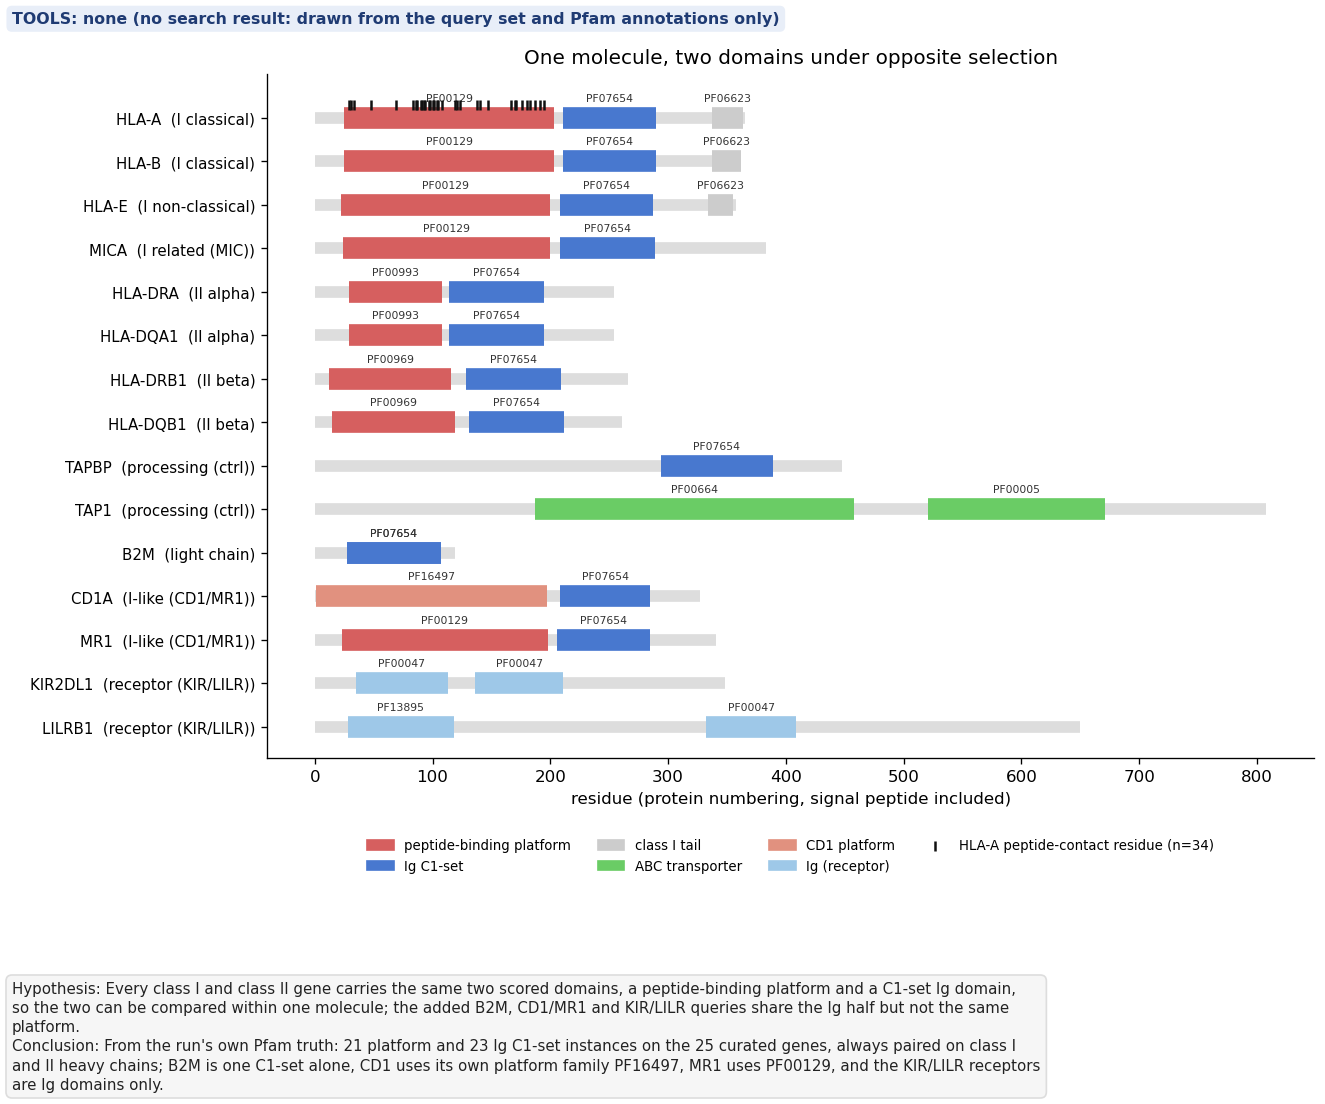

In [3]:
core_truth = truth.join(
    core.select("accession", "hgnc_symbol", "mhc_class"), on="accession", how="inner"
).with_columns(role=mu.domain_role(pl.col("pfam_id")))
extras_truth = truth.join(
    extras.select("accession", "hgnc_symbol", mhc_class="mhc_class_ext"),
    on="accession",
    how="inner",
).with_columns(role=mu.domain_role(pl.col("pfam_id")))
arch = pl.concat([core_truth, extras_truth])

per_gene = (
    core_truth.group_by("hgnc_symbol", "mhc_class")
    .agg(pl.col("pfam_id").sort().alias("pfam_ids"), pl.len().alias("n_domains"))
    .sort("mhc_class", "hgnc_symbol")
)
print("Pfam families per curated MHC gene, from human_domain_truth.parquet:")
with pl.Config(tbl_rows=40, fmt_str_lengths=60, tbl_width_chars=150):
    print(per_gene)

print("\nDomain instances by structural role:")
print(core_truth.group_by("role").len().sort("len", descending=True))
print("\nAll platform + Ig pairings present:")
print(
    core_truth.filter(pl.col("role").is_in(["peptide-binding platform", "Ig C1-set"]))
    .group_by("mhc_class", "role", "pfam_id")
    .len()
    .sort("mhc_class", "role")
)

# --- figure: domain architecture, drawn from the truth-set coordinates ---
show = [
    "HLA-A",
    "HLA-B",
    "HLA-E",
    "MICA",
    "HLA-DRA",
    "HLA-DQA1",
    "HLA-DRB1",
    "HLA-DQB1",
    "TAPBP",
    "TAP1",
    "B2M",
    "CD1A",
    "MR1",
    "KIR2DL1",
    "LILRB1",
]
sub = arch.filter(pl.col("hgnc_symbol").is_in(show))
fig, ax = plt.subplots(figsize=(11, 7.2))
ylabels = []
for i, sym in enumerate(show):
    rows = sub.filter(pl.col("hgnc_symbol") == sym).sort("domain_start")
    if rows.height == 0:
        continue
    L = rows["protein_length"][0]
    ax.plot([0, L], [i, i], color="#dddddd", lw=7, solid_capstyle="butt", zorder=1)
    for r in rows.iter_rows(named=True):
        colour = mu.DOMAIN_ROLE_COLORS.get(r["role"], "#888888")
        ax.plot(
            [r["domain_start"], r["domain_end"]],
            [i, i],
            color=colour,
            lw=13,
            solid_capstyle="butt",
            zorder=2,
        )
        ax.text(
            (r["domain_start"] + r["domain_end"]) / 2,
            i - 0.34,
            r["pfam_id"],
            ha="center",
            va="bottom",
            fontsize=6.5,
            color="#333333",
        )
    ylabels.append(f"{sym}  ({rows['mhc_class'][0]})")

# HLA-A's peptide-contact residues, from ou.CONTACT_PROT, on the top row only.
ax.scatter(
    ou.CONTACT_PROT,
    np.zeros(len(ou.CONTACT_PROT)) - 0.30,
    marker="|",
    s=34,
    color="#111111",
    zorder=5,
    label=f"HLA-A peptide-contact residue (n={len(ou.CONTACT_PROT)})",
)

ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("residue (protein numbering, signal peptide included)")
ax.set_title("One molecule, two domains under opposite selection")
handles = [mpatches.Patch(color=c, label=k) for k, c in mu.DOMAIN_ROLE_COLORS.items()]
handles += ax.get_legend_handles_labels()[0]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=4,
    fontsize=8,
    frameon=False,
)
for s in ("right", "top"):
    ax.spines[s].set_visible(False)
n_plat = core_truth.filter(pl.col("role") == "peptide-binding platform").height
n_ig = core_truth.filter(pl.col("role") == "Ig C1-set").height
mu.finish_figure(
    fig,
    FIG_DIR / "220_mhc_domain_architecture.png",
    tools=mu.NO_TOOL,
    hypothesis=(
        "Every class I and class II gene carries the same two scored domains, a "
        "peptide-binding platform and a C1-set Ig domain, so the two can be compared "
        "within one molecule; the added B2M, CD1/MR1 and KIR/LILR queries share the Ig "
        "half but not the same platform."
    ),
    conclusion=(
        f"From the run's own Pfam truth: {n_plat} platform and {n_ig} Ig C1-set instances "
        f"on the {core.height} curated genes, always paired on class I and II heavy "
        "chains; B2M is one C1-set alone, CD1 uses its own platform family PF16497, MR1 "
        "uses PF00129, and the KIR/LILR receptors are Ig domains only."
    ),
    footer_y=-0.10,
)

## 3. What each target proteome can possibly contain

A recall number is meaningless without the denominator that goes with it. MHC class I and
class II are jawed-vertebrate inventions; a search of *E. coli* cannot find PF00129 because
*E. coli* has no PF00129. Scoring that as a miss punishes the tool for the phylogeny.

The table below is the denominator: for each target proteome, how many instances of each
MHC-relevant Pfam family the run's own domain map contains. `mouse`, `chicken` and
`zebrafish` are the only three targets that can hold a real MHC molecule. From ciona
outward, a hit can only be a more distant relative of the fold, which is a different claim,
and notebook 221 keeps the two separated. The three Ig families the KIR/LILR receptors
carry are added on the right: they are ordinary immunoglobulin-superfamily families and
exist far beyond the vertebrates, which is what makes a receptor hit in an invertebrate
uninformative about the MHC. Botryllus has no Pfam map and no row.

shape: (9, 14)
┌─────────────┬──────┬──────────────────┬─────────┬───┬─────────┬─────────┬─────────┬─────────┐
│ species     ┆ mya  ┆ proteome_domains ┆ PF00129 ┆ … ┆ PF13895 ┆ PF13927 ┆ PF00664 ┆ PF00005 │
│ ---         ┆ ---  ┆ ---              ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str         ┆ i64  ┆ i64              ┆ i64     ┆   ┆ i64     ┆ i64     ┆ i64     ┆ i64     │
╞═════════════╪══════╪══════════════════╪═════════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ mouse       ┆ 100  ┆ 49998            ┆ 37      ┆ … ┆ 74      ┆ 243     ┆ 39      ┆ 89      │
│ chicken     ┆ 300  ┆ 13421            ┆ 2       ┆ … ┆ 6       ┆ 84      ┆ 8       ┆ 15      │
│ zebrafish   ┆ 430  ┆ 28019            ┆ 6       ┆ … ┆ 20      ┆ 136     ┆ 26      ┆ 45      │
│ ciona       ┆ 550  ┆ 20234            ┆ 0       ┆ … ┆ 4       ┆ 55      ┆ 26      ┆ 52      │
│ fly         ┆ 600  ┆ 22096            ┆ 0       ┆ … ┆ 6       ┆ 143     ┆ 40      ┆ 88      │
│ worm        ┆ 650  ┆ 24

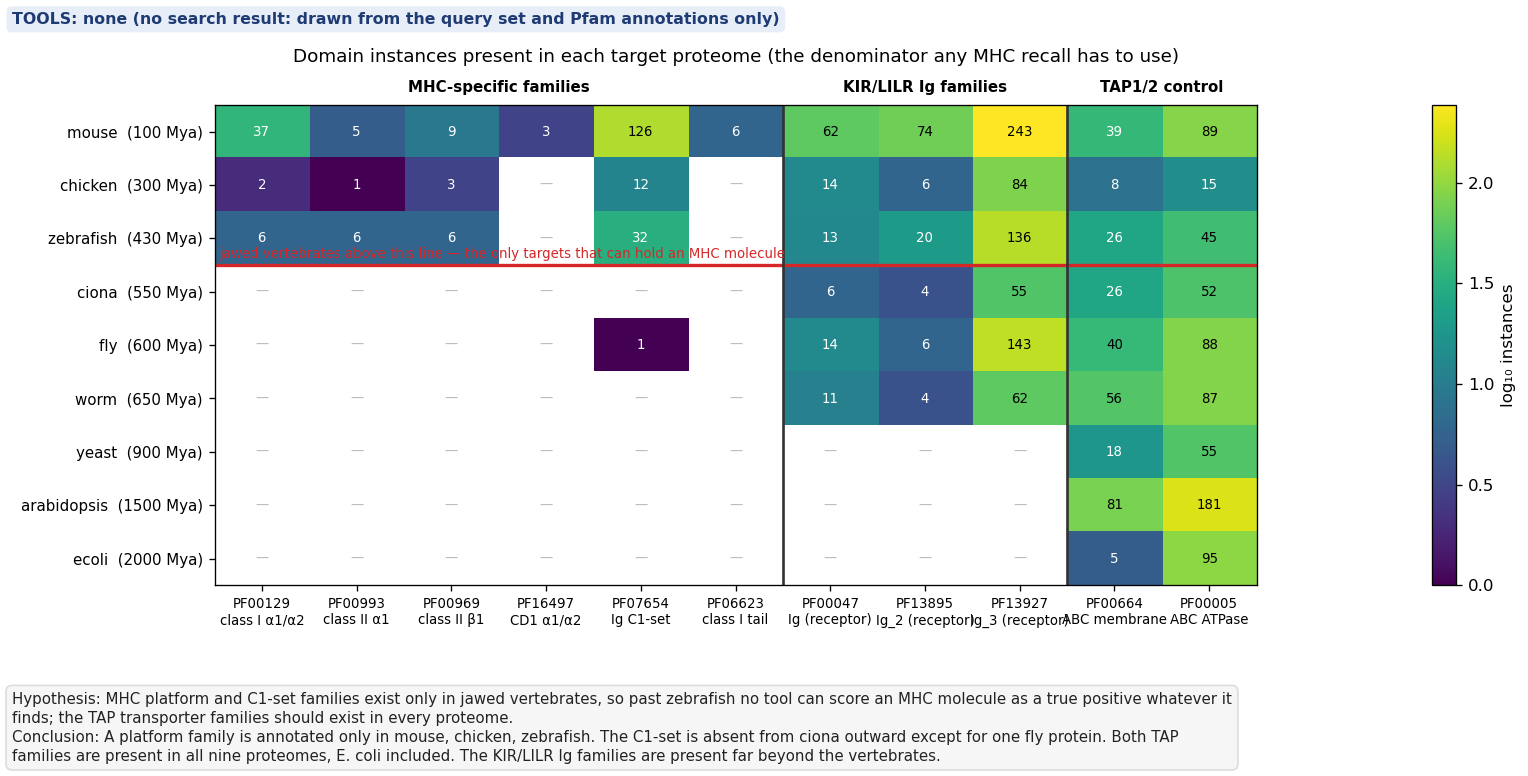

In [4]:
FAMS = (
    list(mu.PFAM_PLATFORM)
    + list(mu.PFAM_PLATFORM_LIKE)
    + [mu.PFAM_IG_C1, mu.PFAM_CLASS_I_TAIL]
    + list(mu.PFAM_IG_RECEPTOR)
    + list(mu.PFAM_TAP)
)
FAM_LABEL = {
    **{k: f"{k}\n{v}" for k, v in mu.PFAM_PLATFORM.items()},
    **{k: f"{k}\n{v}" for k, v in mu.PFAM_PLATFORM_LIKE.items()},
    mu.PFAM_IG_C1: f"{mu.PFAM_IG_C1}\nIg C1-set",
    mu.PFAM_CLASS_I_TAIL: f"{mu.PFAM_CLASS_I_TAIL}\nclass I tail",
    **{k: f"{k}\n{v} (receptor)" for k, v in mu.PFAM_IG_RECEPTOR.items()},
    **{k: f"{k}\n{v}" for k, v in mu.PFAM_TAP.items()},
}

rows = []
for sp in mu.SPECIES_ORDER:
    dm = mu.load_target_domain_map(sp)
    counts = (
        dm.filter(pl.col("pfam_id").is_in(FAMS))
        .group_by("pfam_id")
        .len()
        .rename({"len": "n_instances"})
    )
    d = dict(zip(counts["pfam_id"].to_list(), counts["n_instances"].to_list()))
    rows.append(
        {
            "species": sp,
            "mya": mu.SPECIES_MYA[sp],
            "proteome_domains": dm.height,
            **{f: d.get(f, 0) for f in FAMS},
        }
    )
reach = pl.DataFrame(rows)
with pl.Config(tbl_width_chars=200, tbl_rows=20):
    print(reach)

mat = reach.select(FAMS).to_numpy().astype(float)
fig, ax = plt.subplots(figsize=(13.5, 5.2))
with np.errstate(divide="ignore"):
    shown = np.where(mat > 0, np.log10(mat), np.nan)
im = ax.imshow(shown, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(FAMS)))
ax.set_xticklabels([FAM_LABEL[f] for f in FAMS], fontsize=8)
ax.set_yticks(range(len(mu.SPECIES_ORDER)))
ax.set_yticklabels(
    [f"{s}  ({mu.SPECIES_MYA[s]} Mya)" for s in mu.SPECIES_ORDER], fontsize=9
)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = int(mat[i, j])
        ax.text(
            j,
            i,
            "—" if v == 0 else f"{v:_}",
            ha="center",
            va="center",
            fontsize=8,
            color="#bbbbbb" if v == 0 else ("white" if shown[i, j] < 1.6 else "black"),
        )
ax.axhline(2.5, color="#D62728", lw=2)
ax.text(
    -0.45,
    2.42,
    "jawed vertebrates above this line — the only targets that can hold an MHC molecule",
    color="#D62728",
    fontsize=8,
    va="bottom",
    ha="left",
)
# Three blocks: MHC-specific families, the receptors' generic Ig families, and the
# two ABC columns that are the control. The dividers say so.
n_mhc = len(mu.PFAM_PLATFORM) + len(mu.PFAM_PLATFORM_LIKE) + 2
n_rec = len(mu.PFAM_IG_RECEPTOR)
ax.axvline(n_mhc - 0.5, color="#333333", lw=1.6)
ax.axvline(n_mhc + n_rec - 0.5, color="#333333", lw=1.6)
ax.text(
    (n_mhc - 1) / 2,
    -0.75,
    "MHC-specific families",
    ha="center",
    fontsize=9,
    fontweight="bold",
)
ax.text(
    n_mhc + (n_rec - 1) / 2,
    -0.75,
    "KIR/LILR Ig families",
    ha="center",
    fontsize=9,
    fontweight="bold",
)
ax.text(
    n_mhc + n_rec + 0.5,
    -0.75,
    "TAP1/2 control",
    ha="center",
    fontsize=9,
    fontweight="bold",
)
ax.set_title(
    "Domain instances present in each target proteome (the denominator any MHC recall has to use)",
    fontsize=11,
    pad=26,
)
fig.colorbar(im, ax=ax, label="log₁₀ instances", fraction=0.03, pad=0.14)
plat_cols = list(mu.PFAM_PLATFORM) + list(mu.PFAM_PLATFORM_LIKE)
have_plat = [
    r["species"]
    for r in reach.iter_rows(named=True)
    if any(r[f] > 0 for f in plat_cols)
]
mu.finish_figure(
    fig,
    FIG_DIR / "220_mhc_family_reachability.png",
    tools=mu.NO_TOOL,
    hypothesis=(
        "MHC platform and C1-set families exist only in jawed vertebrates, so past "
        "zebrafish no tool can score an MHC molecule as a true positive whatever it finds; "
        "the TAP transporter families should exist in every proteome."
    ),
    conclusion=(
        f"A platform family is annotated only in {', '.join(have_plat)}. The C1-set is absent "
        "from ciona outward except for one fly protein. Both TAP families are present in "
        "all nine proteomes, E. coli included. The KIR/LILR Ig families are present far "
        "beyond the vertebrates."
    ),
    layout=False,
    footer_y=-0.06,
)

## 4. What midi-plus added, and what the query set still does not cover

**Added since the midi run.** B2M is on chr15 and was missing from the chr6-only midi run,
so "class I" there meant the heavy chain only. midi-plus adds it as its own query set, and
adds two more groups an immunologist will ask about: CD1A-E and MR1, the non-polymorphic
class I-like molecules that present lipids and vitamin metabolites, and the KIR and LILR
receptors that bind class I. None of the three groups is on chromosome 6, so they take no
part in the region figures; they are scored like every other query and appear in notebook
221 as their own block.

Three gaps remain, stated here so no later notebook has to rediscover them.

**Only the primary assembly.** GRCh38 carries eight MHC alt haplotypes
(`ou.HUMAN_MHC_ALT_CONTIGS`), and the whole point of the MHC is that haplotypes differ. The
QfO human reference proteome is one allele per gene.

Class I is a multigene family, and one gene is not one lineage. HLA-A, -B and -C are a
primate-specific expansion of a single ancestral locus. Six class I heavy chains is three
independent lineages, not six. Notebook 215 already made this point and it still applies.

The structure arms cannot see everything the sequence arms can. The AlphaFold DB ships
full-length models only to 2,700 aa and this pipeline keeps fragment F1 only, and ProstT5 is
capped at 6,000 aa. That is not binding on MHC genes, which are all under 810 residues, but
it is binding on the chr6 control set, so a tool comparison over all 964 chr6 genes has to
say so.

B2M in ou.MHC_CLASSES : True
B2M in the query set  : True

The 34 queries midi-plus added off chromosome 6, and their scored Pfam domains:
shape: (34, 5)
┌─────────────┬─────────────────────┬─────────────────────────────────────┬───────────┬────────────┐
│ hgnc_symbol ┆ mhc_class           ┆ pfam_ids                            ┆ n_domains ┆ chromosome │
│ ---         ┆ ---                 ┆ ---                                 ┆ ---       ┆ ---        │
│ str         ┆ str                 ┆ list[str]                           ┆ u32       ┆ str        │
╞═════════════╪═════════════════════╪═════════════════════════════════════╪═══════════╪════════════╡
│ CD1A        ┆ I-like (CD1/MR1)    ┆ ["PF07654", "PF16497"]              ┆ 2         ┆ 1          │
│ CD1B        ┆ I-like (CD1/MR1)    ┆ ["PF07654", "PF16497"]              ┆ 2         ┆ 1          │
│ CD1C        ┆ I-like (CD1/MR1)    ┆ ["PF07654", "PF16497"]              ┆ 2         ┆ 1          │
│ CD1D        ┆ I-like (CD1/MR1)    ┆ 

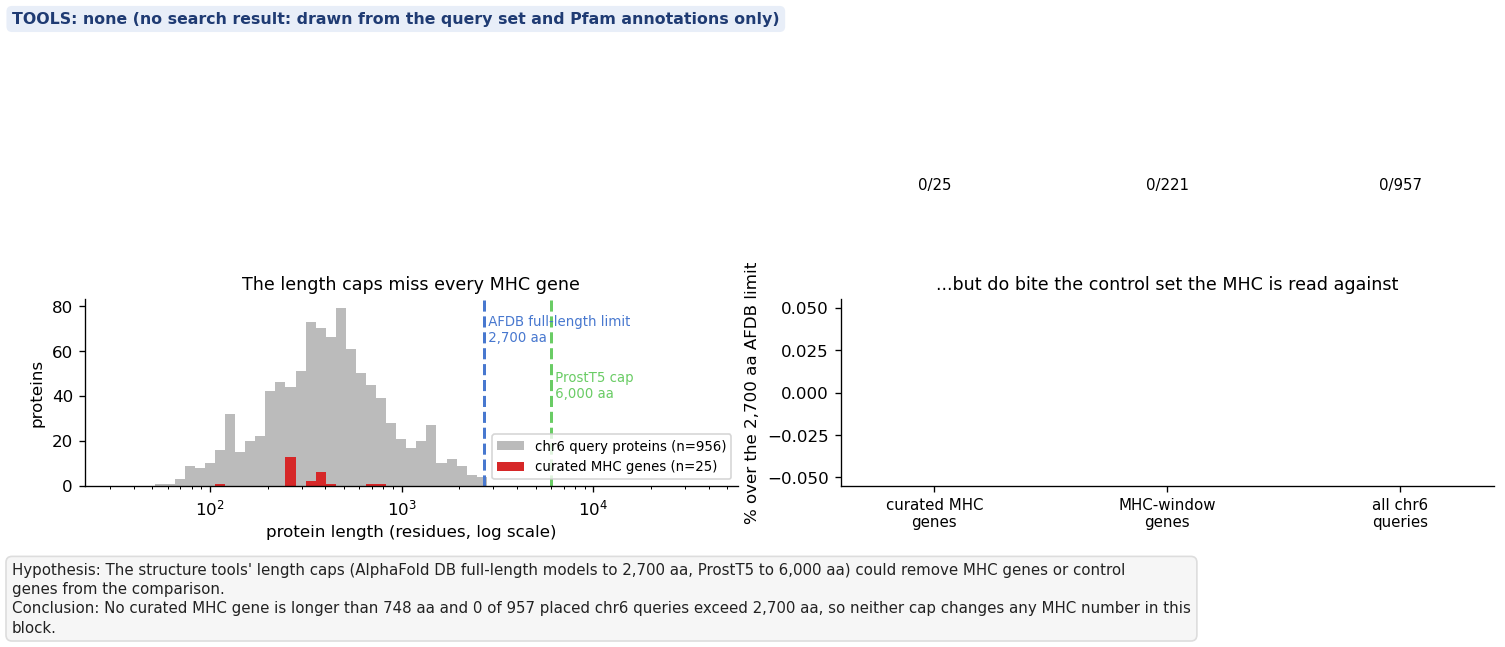

In [5]:
print(f"B2M in ou.MHC_CLASSES : {'B2M' in ou.MHC_CLASSES}")
print(
    f"B2M in the query set  : {gene_map.filter(pl.col('hgnc_symbol') == 'B2M').height > 0}"
)
print(
    "\nThe 34 queries midi-plus added off chromosome 6, and their scored Pfam domains:"
)
with pl.Config(tbl_rows=40, tbl_width_chars=160, fmt_str_lengths=60):
    print(
        extras_truth.group_by("hgnc_symbol", "mhc_class")
        .agg(pl.col("pfam_id").sort().alias("pfam_ids"), pl.len().alias("n_domains"))
        .join(extras.select("hgnc_symbol", "chromosome"), on="hgnc_symbol")
        .sort("mhc_class", "hgnc_symbol")
    )

longest = (
    core.select("hgnc_symbol", "n_residues").sort("n_residues", descending=True).head(3)
)
print("\nLongest curated MHC proteins:")
print(longest)
print(
    f"ProstT5 cap 6000 aa, AFDB full-length limit 2700 aa -> MHC genes affected: "
    f"{core.filter(pl.col('n_residues') > 2700).height}"
)

over = gm.filter(pl.col("n_residues") > 2700)
print(
    f"\nchr6 control genes over the 2,700 aa AFDB limit: {over.height} of {gm.height} "
    f"({100 * over.height / gm.height:.1f}%)"
)
print(
    over.select("hgnc_symbol", "n_residues").sort("n_residues", descending=True).head(5)
)

print("\nClass I heavy chains (n=6 genes, 3 independent lineages):")
print(
    core.filter(pl.col("hgnc_symbol").is_in(ou.MHC_CLASS_I_GENES))
    .select("hgnc_symbol", "mhc_class", "n_residues")
    .sort("hgnc_symbol")
)

# Where the length caps bite. MHC genes are all short; the chr6 control set is not, so a
# tool comparison run over all 964 has to carry this and the MHC figures do not.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
lengths = gm["n_residues"].drop_nulls().to_numpy()
ax.hist(
    lengths,
    bins=np.logspace(1.5, 4.6, 60),
    color="#bbbbbb",
    label=f"chr6 query proteins (n={len(lengths)})",
)
ax.hist(
    core["n_residues"].drop_nulls().to_numpy(),
    bins=np.logspace(1.5, 4.6, 60),
    color="#D62728",
    label=f"curated MHC genes (n={core.height})",
)
ax.axvline(2700, color="#4878CF", lw=1.8, ls="--")
ax.text(
    2700,
    ax.get_ylim()[1] * 0.92,
    " AFDB full-length limit\n 2,700 aa",
    fontsize=8,
    color="#4878CF",
    va="top",
)
ax.axvline(6000, color="#6ACC65", lw=1.8, ls="--")
ax.text(
    6000,
    ax.get_ylim()[1] * 0.62,
    " ProstT5 cap\n 6,000 aa",
    fontsize=8,
    color="#6ACC65",
    va="top",
)
ax.set_xscale("log")
ax.set_xlabel("protein length (residues, log scale)")
ax.set_ylabel("proteins")
ax.set_title("The length caps miss every MHC gene", fontsize=10.5)
ax.legend(fontsize=8)

ax = axes[1]
groups = ["curated MHC\ngenes", "MHC-window\ngenes", "all chr6\nqueries"]
frames = [core, window, gm]
over = [f.filter(pl.col("n_residues") > 2700).height for f in frames]
tot = [f.height for f in frames]
ax.bar(range(3), [100 * o / t for o, t in zip(over, tot)], 0.55, color="#4878CF")
for i, (o, t) in enumerate(zip(over, tot)):
    ax.text(i, 100 * o / t + 0.12, f"{o}/{t}", ha="center", fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel("% over the 2,700 aa AFDB limit")
ax.set_title("...but do bite the control set the MHC is read against", fontsize=10.5)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "220_length_caps.png",
    tools=mu.NO_TOOL,
    hypothesis=(
        "The structure tools' length caps (AlphaFold DB full-length models to 2,700 aa, "
        "ProstT5 to 6,000 aa) could remove MHC genes or control genes from the comparison."
    ),
    conclusion=(
        f"No curated MHC gene is longer than {core['n_residues'].max()} aa and "
        f"{over[2]} of {tot[2]} placed chr6 queries exceed 2,700 aa, so neither cap "
        "changes any MHC number in this block."
    ),
)

## Summary

The midi-plus run puts **998 human proteins** against nine scored proteomes and one
unscored one (Botryllus). **964** are chromosome 6: **221** fall inside the extended MHC,
**736** are the same-chromosome control that every later comparison is read against, and 7
could not be placed. The other **34** are the additions B2M, CD1A-E, MR1 and the KIR/LILR
receptors, none on chromosome 6.

Inside the MHC, the run scores **25 curated MHC genes** (24 on chr6 plus B2M) carrying
**52 Pfam domain instances**. The architecture is uniform and it is what makes the region
worth studying with this pipeline: every class I and class II gene is a fast-evolving
peptide-binding platform bolted to a conserved Ig C1-set domain, searched together, scored
together, under opposite selection. TAP1/TAP2's ABC-transporter domains sit in the same
region as a control that reaches all the way to *E. coli*.

The denominator is not flat. Only **mouse, chicken and zebrafish** contain MHC platform
domains at all. Beyond them a hit is a claim about the fold, not about an MHC molecule, and
notebooks 221 to 226 keep that line visible rather than averaging across it.
